# Chunking das cinco manifestações mais longas

Base **demonstrativa sintética**, autorizada para substituir a base oficial ausente. São 40 manifestações fictícias, seis pares rotulados e cinco textos com mais de 500 caracteres. Os pares M003/M017, M008/M022 e M008/M031 mantêm os temas indicados no enunciado. O gabarito não foi usado para treinar os modelos. Os resultados abaixo são de execução real, não valores ilustrativos.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.metrics.pairwise import cosine_similarity
from ouvidoria import carregar_base, codificar, detectar_duplicatas, dividir, projetar, MODELOS
df = carregar_base()
Path('resultados').mkdir(exist_ok=True)
pd.set_option('display.max_colwidth', 160)
display(df.head())


C:\Users\Usuario\Desktop\ricardo\.venv-validacao\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,data,categoria_oficial,texto
0,M001,2026-08-01,infraestrutura,A calçada da Rua das Flores está quebrada em frente ao número 20. Pessoas com cadeira de rodas precisam circular pela pista.
1,M002,2026-08-02,meio ambiente,"Há lixo acumulado no terreno da Rua do Sol, ao lado do número 45. O descarte atrai moscas e produz mau cheiro."
2,M003,2026-08-03,infraestrutura,"Há um buraco enorme na Av. Brasil, perto do número 100, sentido centro. A cratera causa acidentes e precisa de reparo."
3,M004,2026-08-04,educação,A Escola Municipal Aurora está sem professor de matemática no oitavo ano há três semanas. Pedimos reposição das aulas.
4,M005,2026-08-05,segurança,Moradores relatam assaltos no ponto de ônibus da Rua das Acácias à noite. Solicitamos patrulhamento no local.


O enunciado menciona 500 palavras no contexto e 500 caracteres na descrição da base. Adotamos o critério operacional de caracteres e selecionamos os cinco maiores textos. Comparação principal: (250,0) e (250,50), isolando o efeito do overlap; adicionamos (400,80) para avaliar blocos maiores. A sobreposição é um alvo do splitter, não uma garantia exata em todas as fronteiras.

In [2]:
longas = df.assign(caracteres=df.texto.str.len()).nlargest(5,'caracteres')
display(longas[['id','caracteres','texto']])
linhas, resumos = [], []
for tamanho, overlap in [(250,0),(250,50),(400,80)]:
    for _,item in longas.iterrows():
        chunks = dividir(item.texto,tamanho,overlap)
        emb = codificar(chunks)
        coesao = np.sum(emb[:-1]*emb[1:],axis=1)
        resumos.append({'id':item.id,'tamanho':tamanho,'overlap':overlap,'chunks':len(chunks),'cosseno_consecutivo_medio':float(coesao.mean()) if len(coesao) else np.nan})
        for i,c in enumerate(chunks):
            linhas.append({'id':item.id,'config':f'{tamanho}/{overlap}','chunk':i+1,'caracteres':len(c),'texto':c})
chunks_df = pd.DataFrame(linhas)
resumo = pd.DataFrame(resumos)
display(resumo)
display(chunks_df)
resumo.to_csv('resultados/chunking_metricas.csv',index=False)
chunks_df.to_csv('resultados/chunks.csv',index=False)
display(resumo.groupby(['tamanho','overlap'])[['chunks','cosseno_consecutivo_medio']].mean())


,id,caracteres,texto
38,M039,717,Os moradores próximos ao riacho do Cedro perceberam mudanças na água nas últimas semanas. O líquido apresenta espuma e cheiro forte no trecho atrás do galpã...
39,M040,716,"No entorno do terminal do bairro Campo Verde, os usuários relatam sensação de insegurança no retorno do trabalho. Há trechos sem movimento, pontos com pouca..."
37,M038,712,"Na Escola Municipal das Águas, a biblioteca está fechada desde o início do semestre. Os estudantes não conseguem retirar livros e os professores precisam le..."
36,M037,710,"A unidade de saúde do bairro Floresta enfrenta longas filas para agendamento. Cheguei antes da abertura e já havia dezenas de pessoas esperando na calçada, ..."
35,M036,663,"A Rua das Mangueiras apresenta problemas de drenagem há meses. Quando chove, a água se acumula no trecho em frente à padaria e impede a passagem de pedestre..."


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3206.74it/s]

,id,tamanho,overlap,chunks,cosseno_consecutivo_medio
0,M039,250,0,3,0.567219
1,M040,250,0,4,0.522024
2,M038,250,0,4,0.374291
3,M037,250,0,4,0.331958
4,M036,250,0,4,0.404528
5,M039,250,50,3,0.567219
6,M040,250,50,4,0.522024
7,M038,250,50,4,0.374291
8,M037,250,50,4,0.331958
9,M036,250,50,4,0.404528


,id,config,chunk,caracteres,texto
0,M039,250/0,1,247,Os moradores próximos ao riacho do Cedro perceberam mudanças na água nas últimas semanas. O líquido apresenta espuma e cheiro forte no trecho atrás do galpã...
1,M039,250/0,2,228,. Vimos resíduos acumulados nas margens e animais evitando o local onde costumavam beber água. Não sabemos a origem do despejo e pedimos que a fiscalização ...
2,M039,250/0,3,242,". Solicitamos coleta de amostras, limpeza das margens e orientação à comunidade. Também é necessário instalar avisos sobre as condições do local e informar ..."
3,M040,250/0,1,214,"No entorno do terminal do bairro Campo Verde, os usuários relatam sensação de insegurança no retorno do trabalho. Há trechos sem movimento, pontos com pouca..."
4,M040,250/0,2,173,". Uma passageira informou que procurou ajuda, mas não encontrou equipe de vigilância no horário. O problema afeta especialmente quem precisa esperar a últim..."
5,M040,250/0,3,187,". Solicitamos avaliação do patrulhamento, presença de agentes nos horários de maior espera e melhoria da iluminação dos acessos. Pedimos também um canal vis..."
6,M040,250/0,4,142,". A instalação de câmeras deve ser acompanhada de manutenção e de resposta às chamadas, para que as medidas realmente auxiliem os passageiros."
7,M038,250/0,1,208,"Na Escola Municipal das Águas, a biblioteca está fechada desde o início do semestre. Os estudantes não conseguem retirar livros e os professores precisam le..."
8,M038,250/0,2,174,". A direção informou que há infiltração no teto e que parte das estantes precisou ser removida. Nos dias de chuva, a água alcança as caixas onde foram guard..."
9,M038,250/0,3,171,. Os responsáveis temem a perda do acervo e a interrupção prolongada dos projetos pedagógicos. Solicitamos reparo da cobertura e um espaço provisório seguro...


chunks  cosseno_consecutivo_medio
tamanho overlap                                   
250     0           3.8                   0.440004
        50          3.8                   0.440004
400     80          2.8                   0.589694

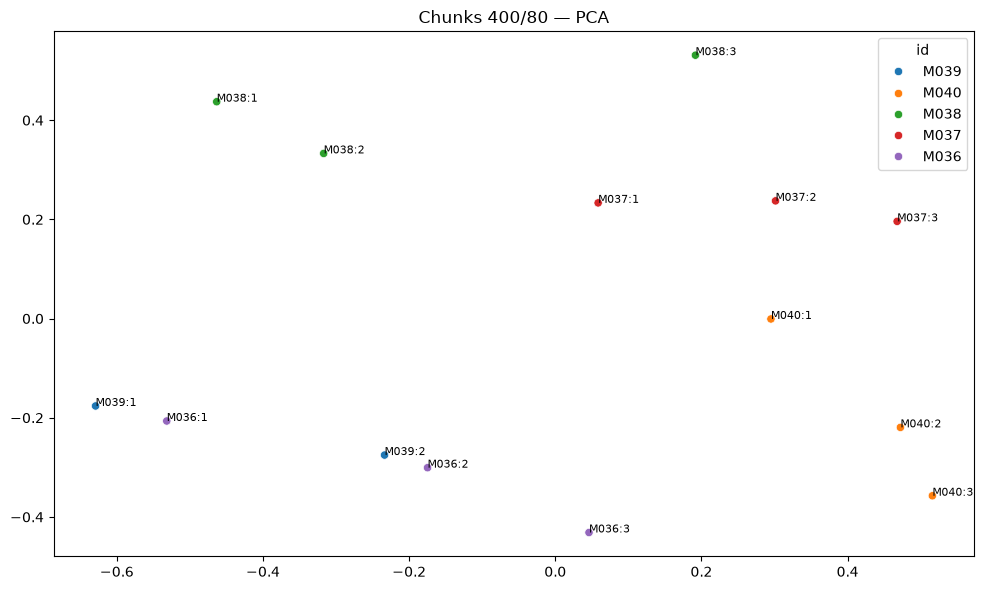

Cosseno médio entre chunks da mesma manifestação: **0.549**; entre manifestações diferentes: **0.367**. A proximidade é avaliada no espaço original; a projeção pode distorcer a relação.

,config,chunk,texto
15,250/0,1,"A Rua das Mangueiras apresenta problemas de drenagem há meses. Quando chove, a água se acumula no trecho em frente à padaria e impede a passagem de pedestre..."
16,250/0,2,. A correnteza leva lixo para dentro das casas mais baixas e danifica móveis. Uma moradora com dificuldade de locomoção depende dos vizinhos para sair de casa
17,250/0,3,". Solicitamos uma vistoria da equipe técnica, limpeza da rede e avaliação do nivelamento do pavimento"
18,250/0,4,". Também pedimos sinalização provisória enquanto o serviço não for realizado, pois motoristas não percebem a profundidade da água e passam em velocidade ele..."
34,250/50,1,"A Rua das Mangueiras apresenta problemas de drenagem há meses. Quando chove, a água se acumula no trecho em frente à padaria e impede a passagem de pedestre..."
35,250/50,2,. A correnteza leva lixo para dentro das casas mais baixas e danifica móveis. Uma moradora com dificuldade de locomoção depende dos vizinhos para sair de casa
36,250/50,3,". Solicitamos uma vistoria da equipe técnica, limpeza da rede e avaliação do nivelamento do pavimento"
37,250/50,4,". Também pedimos sinalização provisória enquanto o serviço não for realizado, pois motoristas não percebem a profundidade da água e passam em velocidade ele..."
49,400/80,1,"A Rua das Mangueiras apresenta problemas de drenagem há meses. Quando chove, a água se acumula no trecho em frente à padaria e impede a passagem de pedestre..."
50,400/80,2,. A correnteza leva lixo para dentro das casas mais baixas e danifica móveis. Uma moradora com dificuldade de locomoção depende dos vizinhos para sair de ca...


In [3]:
selecionados = chunks_df[chunks_df.config=='400/80'].copy()
emb = codificar(selecionados.texto)
xy = projetar(emb,'PCA')
plt.figure(figsize=(10,6))
sns.scatterplot(x=xy[:,0],y=xy[:,1],hue=selecionados.id)
for k,(_,r) in enumerate(selecionados.iterrows()):
    plt.annotate(f'{r.id}:{r.chunk}',xy[k],fontsize=8)
plt.title('Chunks 400/80 — PCA')
plt.tight_layout(); plt.savefig('resultados/chunks_pca.png',dpi=160); plt.show()
sim = emb @ emb.T
mesmo = selecionados.id.to_numpy()[:,None] == selecionados.id.to_numpy()[None,:]
tri = np.triu(np.ones_like(sim,dtype=bool),1)
intra, inter = float(sim[tri & mesmo].mean()),float(sim[tri & ~mesmo].mean())
display(Markdown(f'Cosseno médio entre chunks da mesma manifestação: **{intra:.3f}**; entre manifestações diferentes: **{inter:.3f}**. A proximidade é avaliada no espaço original; a projeção pode distorcer a relação.'))
Path('resultados/chunks_proximidade.json').write_text(json.dumps({'intra':intra,'inter':inter}))
display(chunks_df[chunks_df.id=='M036'][['config','chunk','texto']])


**Conclusão.** Recomenda-se 400/80 para estes textos curtos: blocos maiores mantêm juntos mais elementos do relato (problema, local e pedido), com overlap moderado para reduzir perda nas fronteiras. Em M036, o relato conecta alagamento, danos às casas e pedido de vistoria; os trechos exibidos permitem conferir onde essas relações foram separadas. Em 250/0, nenhuma repetição auxilia uma consulta que dependa de contexto na fronteira. Em 250/50, a repetição pode melhorar continuidade, mas também aumenta armazenamento e infla similaridade por reutilizar palavras. A média de cosseno não mede sozinha preservação do sentido: texto repetido pode subir o indicador sem acrescentar informação. O teste pareado 250/0 versus 250/50 isola overlap; 400/80 altera também o tamanho. A escolha final é qualitativa e deve ser validada com consultas rotuladas; blocos ainda maiores podem misturar assuntos e exceder o limite de tokens do modelo. Os embeddings usam truncamento do modelo, por isso limites em caracteres não equivalem a limites em tokens.

### O que ocorreu com o overlap nesta execução
+
+As configurações **250/0 e 250/50 produziram exatamente os mesmos chunks** nas cinco manifestações. O splitter priorizou sentenças; o segmento anterior não coube na janela de sobreposição de 50 caracteres. Portanto, a média de cosseno ficou idêntica e **não houve melhora observada de coesão** ao mudar apenas esse parâmetro. Overlap configurado não significa overlap efetivo. Para demonstrar mais repetição, uma investigação posterior pode aumentar a janela ou priorizar separação por palavras, comparando os textos retornados. Em 400/80, o cosseno médio entre chunks do mesmo relato foi **0,549**, contra **0,367** entre relatos diferentes. Isso indica proximidade média, não garante que todos os chunks de cada relato formem um grupo separado.